# Calibration

The full trial sequence mirrors the experimental procedure: film encoding, break items that model the retention interval, start-of-list reinstatement followed by a reminder that reinstates film context, interference encoding, filler events that suppress recency artefacts, and free recall.
Each component is necessary for the paradigm to isolate context-overlap interference from mere recency effects.
This section calibrates each component and establishes a baseline.

In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from jax import random

from jaxcmr.analyses.spc import fixed_pres_spc
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data
from jaxcmr.selective_interference import (
    Paradigm,
    add_filler_boundary,
    break_extended_remap,
    compute_n_presented,
    configure_rates,
    filler_extended_remap,
    film_recalled_stats,
    load_or_fit_params,
    make_extended_break,
    make_extended_filler,
    make_factory,
    plot_interference_spc,
    plot_summary_dv,
    prepare_sweep,
    run_sweep,
    standard_remap,
    sweep_rngs,
)

warnings.filterwarnings("ignore")

In [2]:
# --- paradigm geometry ---
N_FILM = 16
N_BREAK = 16
N_BREAK_MAX = 32
N_INTERFERENCE = 16
N_FILLER = 16
N_FILLER_MAX = 32
EXPERIMENT_COUNT = 100
SHOW_BREAK_IN_SPC = True
SHOW_FILLERS_IN_SPC = True

# --- default scale factors for non-swept phases ---
DEFAULT_BREAK_DRIFT_SCALE = 1.0
DEFAULT_BREAK_MCF_SCALE = 1.0
DEFAULT_REMINDER_START_DRIFT_SCALE = 4.0
DEFAULT_REMINDER_DRIFT_SCALE = 0.3
DEFAULT_FILLER_DRIFT_SCALE = 1.0
DEFAULT_FILLER_MCF_SCALE = 1.0

# --- fitted parameter scales ---
PARAM_SCALES = {
    "stop_probability_scale": 0.57,
}

# --- fitting ---
SEED = 0
DATA_TAG = "HealeyKahana2014"
DATA_PATH = "data/HealeyKahana2014.h5"
TRIAL_QUERY = "data['listtype'] == -1"
MODEL_NAME = "WeirdCMRPosStop"
BEST_OF = 1
RUN_TAG = f"best_of_{BEST_OF}"
REDO_FITS = False

## Setup

In [3]:
# --- derived objects ---
paradigm = Paradigm(
    n_film=N_FILM,
    n_break=N_BREAK,
    n_interference=N_INTERFERENCE,
    n_filler=N_FILLER,
    n_break_max=N_BREAK_MAX,
    n_filler_max=N_FILLER_MAX,
    experiment_count=EXPERIMENT_COUNT,
)

N_BREAK_SHOWN = N_BREAK if SHOW_BREAK_IN_SPC else 0
STD_PRESENTED = compute_n_presented(
    paradigm,
    show_break=SHOW_BREAK_IN_SPC,
    show_fillers=SHOW_FILLERS_IN_SPC,
)

project_root = Path(find_project_root())
fit_dir = Path("results/fits")
fit_dir.mkdir(parents=True, exist_ok=True)
fit_path = fit_dir / f"{DATA_TAG}_{MODEL_NAME}_{RUN_TAG}.json"

data = load_data(str(project_root / DATA_PATH))
trial_mask = generate_trial_mask(data, TRIAL_QUERY)
factory = make_factory()
rng = random.PRNGKey(SEED)

params, n_subjects = load_or_fit_params(
    fit_path,
    param_scales=PARAM_SCALES,
    data=data,
    trial_mask=trial_mask,
    model_factory=factory,
    redo_fits=REDO_FITS,
    best_of=BEST_OF,
)
print(f"{n_subjects} subjects")

Loaded fits from results/fits/HealeyKahana2014_WeirdCMRPosStop_best_of_1.json
  Scaled stop_probability_scale by 0.57
126 subjects


In [4]:
# Pre-cache scales shared by all standard-tier sweeps
_pre_cache_scales = dict(
    break_drift_scale=DEFAULT_BREAK_DRIFT_SCALE,
    break_mcf_scale=DEFAULT_BREAK_MCF_SCALE,
    reminder_start_drift_scale=DEFAULT_REMINDER_START_DRIFT_SCALE,
    reminder_drift_scale=DEFAULT_REMINDER_DRIFT_SCALE,
)

# Standard-tier cached models (reminder pre-cached; used by cells that
# don't sweep reminder parameters: paradigm validation, baseline)
std_prep = prepare_sweep(
    params,
    paradigm,
    factory,
    cache_after="reminder",
    **_pre_cache_scales,
)
print(
    f"Standard tier cached: {n_subjects} subjects (list_length={paradigm.list_length})"
)

# Break-tier cached models (reminder is post-cache; used by
# start-drift and reminder-drift sweeps)
break_prep = prepare_sweep(
    params,
    paradigm,
    factory,
    cache_after="break",
    break_drift_scale=DEFAULT_BREAK_DRIFT_SCALE,
    break_mcf_scale=DEFAULT_BREAK_MCF_SCALE,
)
print(
    f"Break tier cached: {n_subjects} subjects (cache_after='break')"
)

Standard tier cached: 126 subjects (list_length=64)
Break tier cached: 126 subjects (cache_after='break')


## Calibrating break item count

Break items model the structured break between film viewing and the intervention (e.g., mood questionnaire, filler tasks). They push context away from the film region via normal encoding, creating a temporal gap that the reminder must bridge. More break items means more context drift away from film, increasing the need for the reminder to reinstate film context before interference encoding.

This sweep varies the number of break items from 0 to 32. At 0 break items, context stays at end-of-film and the reminder has little work to do. At higher counts, context drifts progressively further from the film region. Break encoding uses the subject's fitted parameters at their default scale.

In [5]:
break_count_values = np.arange(0, N_BREAK_MAX + 1, 4)
print(f"Break count sweep values: {break_count_values}")

# Break-extended paradigm (break slots at ceiling)
brk_paradigm = Paradigm(
    n_film=N_FILM,
    n_break=N_BREAK,
    n_break_max=N_BREAK_MAX,
    n_interference=N_INTERFERENCE,
    n_filler=N_FILLER,
    experiment_count=EXPERIMENT_COUNT,
)
BREAK_SWEEP_PRESENTED = compute_n_presented(
    brk_paradigm,
    n_break=N_BREAK_MAX,
    show_break=SHOW_BREAK_IN_SPC,
    show_fillers=SHOW_FILLERS_IN_SPC,
)

# Cache after film — break items vary per sweep value
brk_prep = prepare_sweep(
    params,
    brk_paradigm,
    factory,
    cache_after="film",
    tier="break_extended",
    break_drift_scale=DEFAULT_BREAK_DRIFT_SCALE,
    break_mcf_scale=DEFAULT_BREAK_MCF_SCALE,
    reminder_start_drift_scale=DEFAULT_REMINDER_START_DRIFT_SCALE,
    reminder_drift_scale=DEFAULT_REMINDER_DRIFT_SCALE,
)

sweep_break_spcs = []
sweep_break_stats = []

for n_brk in break_count_values:
    break_items = make_extended_break(brk_paradigm, int(n_brk))
    custom_args = (break_items,) + brk_prep.item_args[1:]
    rngs_2d, rng = sweep_rngs(rng, n_subjects, EXPERIMENT_COUNT)
    recalls_3d = brk_prep.batched(brk_prep.models, rngs_2d, *custom_args)
    recalls = recalls_3d.reshape(-1, recalls_3d.shape[-1])
    recalls = break_extended_remap(recalls, brk_paradigm, n_break=N_BREAK_MAX)
    sweep_break_spcs.append(fixed_pres_spc(recalls, BREAK_SWEEP_PRESENTED))
    sweep_break_stats.append(film_recalled_stats(recalls, brk_paradigm, n_subjects))

print("Break count sweep done")

Break count sweep values: [ 0  4  8 12 16 20 24 28 32]
Break count sweep done


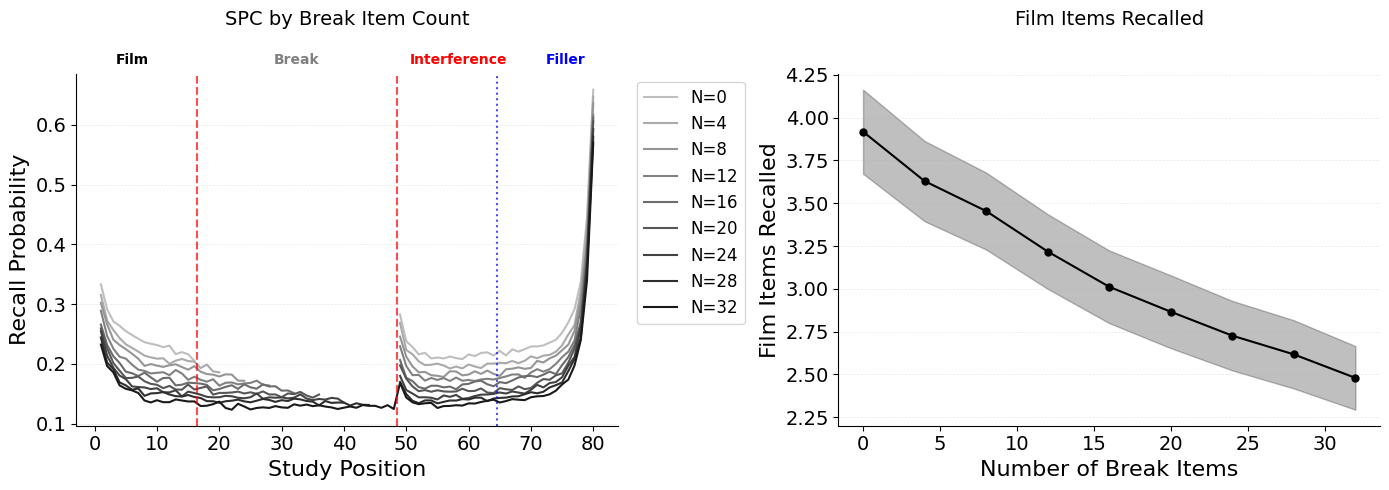

In [6]:
labels = [f"N={n}" for n in break_count_values]
means, ci_lo, ci_hi = zip(*sweep_break_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_interference_spc(
    sweep_break_spcs,
    labels,
    N_FILM,
    n_break=N_BREAK_MAX if SHOW_BREAK_IN_SPC else 0,
    axis=axes[0],
)
add_filler_boundary(
    axes[0],
    N_FILM,
    N_INTERFERENCE,
    N_FILLER,
    BREAK_SWEEP_PRESENTED,
    n_break=N_BREAK_MAX if SHOW_BREAK_IN_SPC else 0,
)
axes[0].set_title("SPC by Break Item Count", fontsize=14, pad=35)

plot_summary_dv(
    break_count_values,
    means,
    ci_lo,
    ci_hi,
    xlabel="Number of Break Items",
    axis=axes[1],
)
axes[1].set_title("Film Items Recalled", fontsize=14, pad=35)

plt.tight_layout()
plt.show()

## Calibrating post-interference filler count

Without filler events between interference encoding and recall, interference items benefit from a strong recency advantage — they were the most recently encoded items, so their context states are maximally similar to the retrieval probe at test onset.
Filler items simulate everyday events between the interference task and the recall test.
By encoding additional items after the interference phase, fillers push interference items out of the recency window, forcing any remaining interference to arise from contextual overlap with the film region rather than temporal proximity.

This sweep varies the number of post-interference filler items from 0 to 32 to determine how many are needed.
Filler encoding uses the subject's fitted parameters at their default scale.

In [7]:
filler_count_values = np.arange(0, N_FILLER_MAX + 1, 4)
print(f"Filler count sweep values: {filler_count_values}")

# Filler-extended paradigm (filler slots at ceiling)
fext_paradigm = Paradigm(
    n_film=N_FILM,
    n_break=N_BREAK,
    n_interference=N_INTERFERENCE,
    n_filler=N_FILLER,
    n_filler_max=N_FILLER_MAX,
    experiment_count=EXPERIMENT_COUNT,
)
FILLER_PRESENTED_WITH = compute_n_presented(
    fext_paradigm,
    n_filler=N_FILLER_MAX,
    show_break=SHOW_BREAK_IN_SPC,
    show_fillers=True,
)
FILLER_PRESENTED_WITHOUT = compute_n_presented(
    fext_paradigm,
    show_break=SHOW_BREAK_IN_SPC,
    show_fillers=False,
)

# Cache through reminder, vary filler items in-trial
fext_prep = prepare_sweep(
    params,
    fext_paradigm,
    factory,
    cache_after="reminder",
    tier="filler_extended",
    **_pre_cache_scales,
)

sweep_filler_spcs_with = []
sweep_filler_spcs_without = []
sweep_filler_stats = []

for n_fill in filler_count_values:
    filler_items = make_extended_filler(fext_paradigm, int(n_fill))
    # item_args = (interf_items, filler_items, max_recall); override filler_items
    custom_args = (fext_prep.item_args[0], filler_items) + fext_prep.item_args[2:]
    rngs_2d, rng = sweep_rngs(rng, n_subjects, EXPERIMENT_COUNT)
    recalls_3d = fext_prep.batched(fext_prep.models, rngs_2d, *custom_args)
    recalls = recalls_3d.reshape(-1, recalls_3d.shape[-1])
    recalls = filler_extended_remap(recalls, fext_paradigm)
    sweep_filler_spcs_without.append(fixed_pres_spc(recalls, FILLER_PRESENTED_WITHOUT))
    sweep_filler_spcs_with.append(fixed_pres_spc(recalls, FILLER_PRESENTED_WITH))
    sweep_filler_stats.append(film_recalled_stats(recalls, fext_paradigm, n_subjects))

print("Filler count sweep done")

Filler count sweep values: [ 0  4  8 12 16 20 24 28 32]
Filler count sweep done


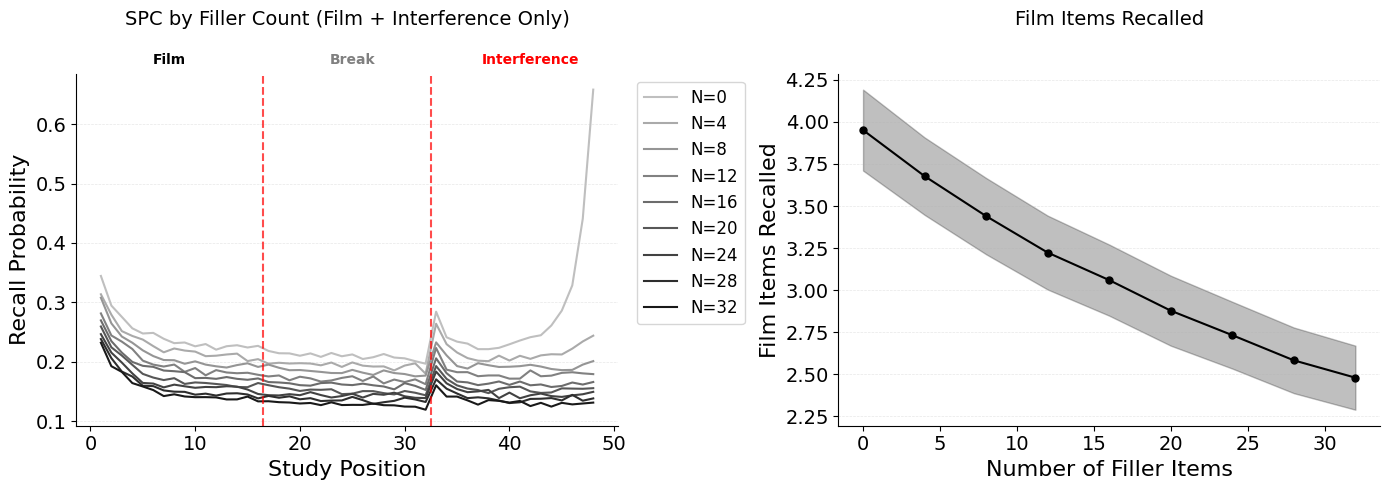

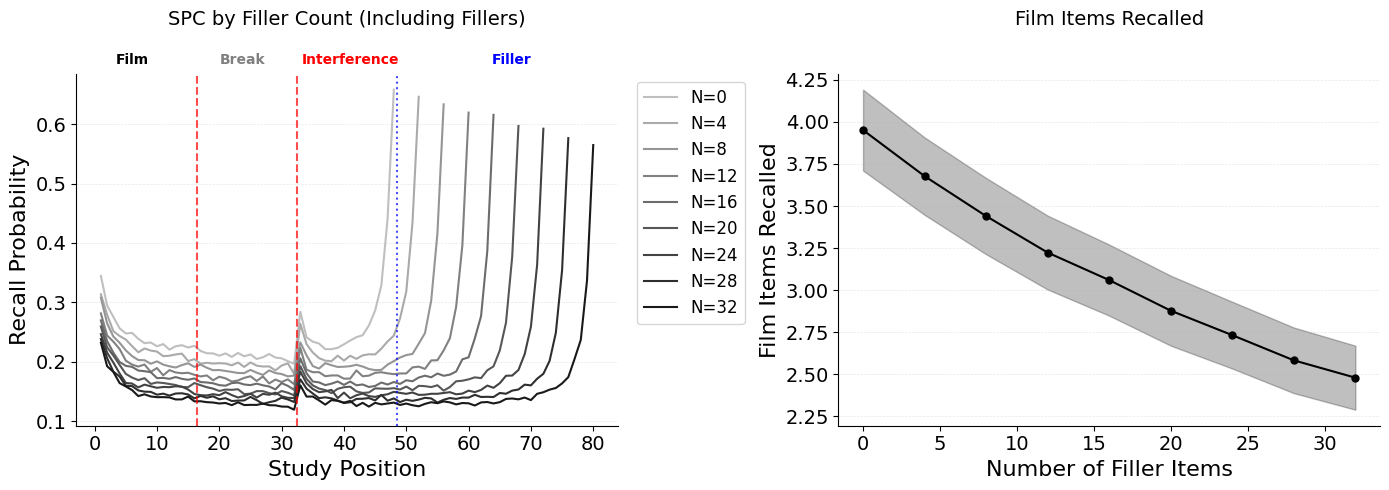

In [8]:
labels = [f"N={n}" for n in filler_count_values]
means, ci_lo, ci_hi = zip(*sweep_filler_stats)

# Plot 1: without fillers in SPC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_interference_spc(
    sweep_filler_spcs_without, labels, N_FILM, n_break=N_BREAK_SHOWN, axis=axes[0]
)
axes[0].set_title("SPC by Filler Count (Film + Interference Only)", fontsize=14, pad=35)
plot_summary_dv(
    filler_count_values,
    means,
    ci_lo,
    ci_hi,
    xlabel="Number of Filler Items",
    axis=axes[1],
)
axes[1].set_title("Film Items Recalled", fontsize=14, pad=35)
plt.tight_layout()
plt.show()

# Plot 2: with fillers in SPC
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
n_presented_filler = [
    N_FILM + N_BREAK_SHOWN + N_INTERFERENCE + int(n) for n in filler_count_values
]
plot_interference_spc(
    sweep_filler_spcs_with,
    labels,
    N_FILM,
    n_break=N_BREAK_SHOWN,
    n_presented=n_presented_filler,
    axis=axes[0],
)
add_filler_boundary(
    axes[0],
    N_FILM,
    N_INTERFERENCE,
    N_FILLER_MAX,
    FILLER_PRESENTED_WITH,
    n_break=N_BREAK_SHOWN,
)
axes[0].set_title("SPC by Filler Count (Including Fillers)", fontsize=14, pad=35)
plot_summary_dv(
    filler_count_values,
    means,
    ci_lo,
    ci_hi,
    xlabel="Number of Filler Items",
    axis=axes[1],
)
axes[1].set_title("Film Items Recalled", fontsize=14, pad=35)
plt.tight_layout()
plt.show()

## Pre-interference context state: break and reminder

A separate question from interference intensity is *which film items* are most vulnerable.
The answer lies in the context state at the moment competitors are encoded.
Two parameters control this:

- **`reminder_start_drift_scale`** — a scale over each subject's fitted `start_drift_rate`, controlling how much context drifts toward start-of-list before the reminder begins.
This orients context back to the beginning of the film sequence so that the reminder can reinstate context across the full film, rather than starting from the post-break state.

- **`reminder_drift_scale`** — a scale over each subject's fitted `encoding_drift_rate`, controlling how strongly the reminder reinstates film context.
At low scales, the reminder has little effect; at high scales, context is driven back through the film sequence, arriving at a state resembling end-of-film encoding.

The retention interval is modeled by break items encoded between film and reminder — these push context away from the film region via normal encoding.
Together with the start-of-list reinstatement and reminder, they give continuous control over the pre-interference context landscape.
The break drifts context away from film; the start-of-list reinstatement orients back; the reminder drives context through the film sequence.

Importantly, reminders modulate interference *targeting* (which film items are most vulnerable) rather than interference *intensity* (how many film items are recalled) — total film recall is relatively stable across the reminder sweep, but the SPC shape shifts.
This demonstrates that delayed interference does not require a reconsolidation window: the reminder reinstates context overlap, creating the conditions for effective competition (consistent with James et al. 2015).

### Sweeping start-of-list drift scale

How much does the start-of-list reinstatement before the reminder matter? At low scales, context stays near the post-break state — the reminder begins from wherever the break left context. At high scales, context is driven toward start-of-list before the reminder begins, allowing the reminder to traverse the full film sequence from the beginning. The reminder drift scale is held at its default throughout this sweep.

In [9]:
start_drift_scale_values = np.linspace(0.01, 4.0, 10)
print(f"Start-of-list drift scale sweep values: {start_drift_scale_values.round(2)}")

sds_recalls_4d, rng = run_sweep(
    break_prep, rng,
    reminder_start_drift_scale=start_drift_scale_values,
    reminder_drift_scale=DEFAULT_REMINDER_DRIFT_SCALE,
    filler_drift_scale=DEFAULT_FILLER_DRIFT_SCALE,
    filler_mcf_scale=DEFAULT_FILLER_MCF_SCALE,
)

sweep_start_spcs = []
sweep_start_stats = []
for i in range(len(start_drift_scale_values)):
    recalls = sds_recalls_4d[i].reshape(-1, sds_recalls_4d.shape[-1])
    recalls = standard_remap(recalls, paradigm)
    sweep_start_spcs.append(fixed_pres_spc(recalls, STD_PRESENTED))
    sweep_start_stats.append(film_recalled_stats(recalls, paradigm, n_subjects))

print("Start-of-list drift scale sweep done")

Start-of-list drift scale sweep values: [0.01 0.45 0.9  1.34 1.78 2.23 2.67 3.11 3.56 4.  ]
Start-of-list drift scale sweep done


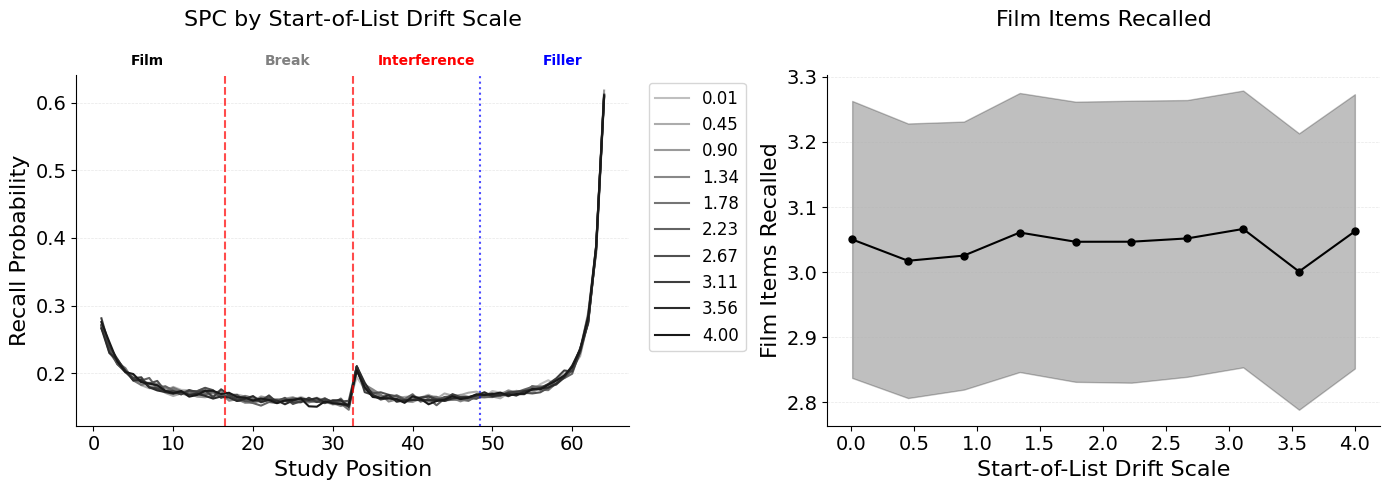

In [10]:
labels = [f"{v:.2f}" for v in start_drift_scale_values]
means, ci_lo, ci_hi = zip(*sweep_start_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_interference_spc(
    sweep_start_spcs, labels, N_FILM, n_break=N_BREAK_SHOWN, axis=axes[0]
)
add_filler_boundary(
    axes[0], N_FILM, N_INTERFERENCE, N_FILLER, STD_PRESENTED, n_break=N_BREAK_SHOWN
)
axes[0].set_title("SPC by Start-of-List Drift Scale", fontsize=16, pad=35)

plot_summary_dv(
    start_drift_scale_values,
    means,
    ci_lo,
    ci_hi,
    xlabel="Start-of-List Drift Scale",
    axis=axes[1],
)
axes[1].set_title("Film Items Recalled", fontsize=16, pad=35)
plt.tight_layout()
plt.show()

### Sweeping reminder drift scale

With the delay drift scale held at its default, this sweep varies how strongly the reminder reinstates film context. At low scales, context barely moves from the post-delay state. At high scales, context drifts rapidly through the film sequence, arriving at a state dominated by the last few film items. Because interference items are subsequently encoded in this context, the reminder drift scale controls how much contextual overlap exists between film and interference items.

The start-of-list drift scale is held at its default throughout this sweep.

In [11]:
reminder_scale_values = np.linspace(0.01, 1.8, 10)
print(f"Reminder drift scale sweep values: {reminder_scale_values.round(3)}")

rem_recalls_4d, rng = run_sweep(
    break_prep, rng,
    reminder_drift_scale=reminder_scale_values,
    reminder_start_drift_scale=DEFAULT_REMINDER_START_DRIFT_SCALE,
    filler_drift_scale=DEFAULT_FILLER_DRIFT_SCALE,
    filler_mcf_scale=DEFAULT_FILLER_MCF_SCALE,
)

sweep_rem_spcs = []
sweep_rem_stats = []
for i in range(len(reminder_scale_values)):
    recalls = rem_recalls_4d[i].reshape(-1, rem_recalls_4d.shape[-1])
    recalls = standard_remap(recalls, paradigm)
    sweep_rem_spcs.append(fixed_pres_spc(recalls, STD_PRESENTED))
    sweep_rem_stats.append(film_recalled_stats(recalls, paradigm, n_subjects))

print("Reminder drift scale sweep done")

Reminder drift scale sweep values: [0.01  0.209 0.408 0.607 0.806 1.004 1.203 1.402 1.601 1.8  ]
Reminder drift scale sweep done


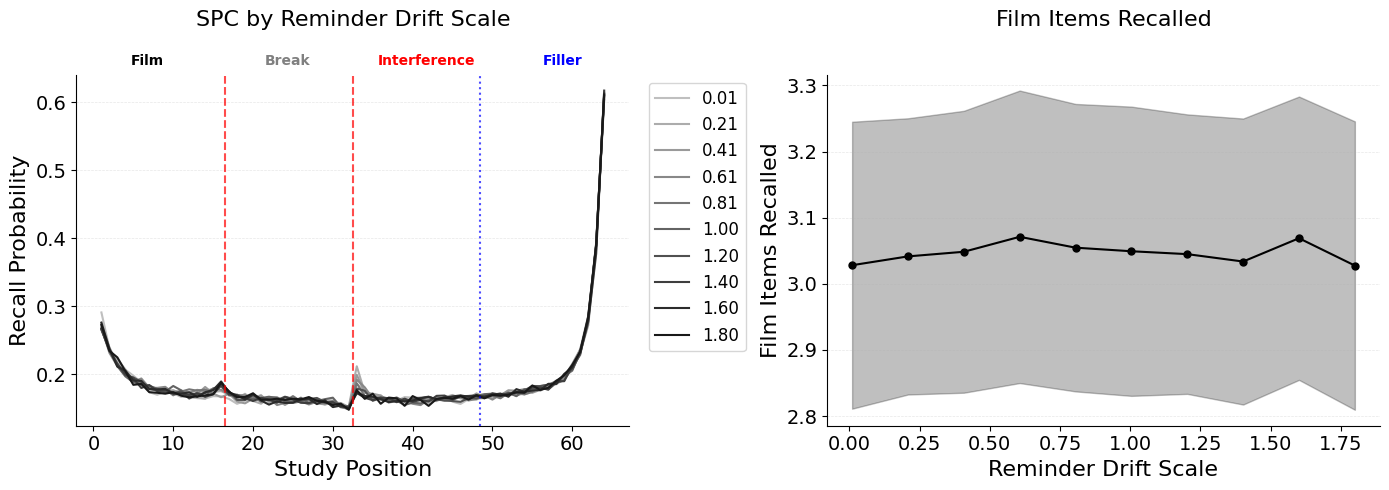

In [12]:
labels = [f"{v:.2f}" for v in reminder_scale_values]
means, ci_lo, ci_hi = zip(*sweep_rem_stats)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
plot_interference_spc(sweep_rem_spcs, labels, N_FILM, n_break=N_BREAK_SHOWN, axis=axes[0])
add_filler_boundary(
    axes[0], N_FILM, N_INTERFERENCE, N_FILLER, STD_PRESENTED, n_break=N_BREAK_SHOWN
)
axes[0].set_title("SPC by Reminder Drift Scale", fontsize=16, pad=35)

plot_summary_dv(
    reminder_scale_values,
    means,
    ci_lo,
    ci_hi,
    xlabel="Reminder Drift Scale",
    axis=axes[1],
)
axes[1].set_title("Film Items Recalled", fontsize=16, pad=35)
plt.tight_layout()
plt.show()

#### Context state summary

The film-item context plot reveals what the reminder drift scale does to context before interference begins. At low scales, context stays near the post-break/post-reinstatement state — recall is concentrated at the positions most activated by that state. At high scales, context drifts through the full film sequence and arrives at a state resembling end-of-film context, producing a recency-weighted recall profile across film positions.

Together, the break items, start-of-list reinstatement, and reminder drift scale give continuous control over pre-interference context state. Break items push context away from the film region, modeling the retention interval. The start-of-list reinstatement orients context back to the beginning of the film. The reminder then drives context through the film sequence, restoring contextual overlap and increasing the vulnerability of late-film items. The total number of film items recalled is relatively stable across the reminder sweep: the reminder redistributes *which* film items are recalled but has limited effect on *how many*. This confirms that reminders modulate interference targeting, not interference intensity.

This has implications for the delayed-interference paradigm: delayed interference does not require a reconsolidation window. Instead, the reminder reinstates context overlap, creating the conditions for effective competition between film and interference items.

## Paradigm validation: delayed interference requires the reminder

The break/reminder mechanism raises a key question: is the reminder necessary for delayed interference, or would competitors encoded after a break still impair film recall?
We compare two conditions:

1. **Reminder + competitors** — the standard paradigm: break, start-of-list reinstatement, reminder, then interference items.
2. **No reminder + competitors** — break, then interference items directly (no start-of-list reinstatement, no reminder).

If the reminder is necessary, condition 2 should show little or no interference: after the break, context has drifted far from the film region, so competitors lack the contextual overlap needed to compete at retrieval.
This would be consistent with James et al. (2015), who found that delayed Tetris reduced intrusions only when preceded by a reminder.

In [13]:
# Condition 1: Reminder + competitors (uses std_prep)
rngs_2d, rng = sweep_rngs(rng, n_subjects, EXPERIMENT_COUNT)
reminded_recalls_3d = std_prep.batched(std_prep.models, rngs_2d, *std_prep.item_args)
reminded_recalls = reminded_recalls_3d.reshape(-1, reminded_recalls_3d.shape[-1])
reminded_recalls = standard_remap(reminded_recalls, paradigm)
reminded_spc = fixed_pres_spc(reminded_recalls, STD_PRESENTED)
reminded_stats = film_recalled_stats(reminded_recalls, paradigm, n_subjects)

# Condition 2: No reminder + competitors (both reminder scales = 0)
no_rem_models = configure_rates(
    break_prep.models,
    reminder_start_drift_scale=0.0,
    reminder_drift_scale=0.0,
    filler_drift_scale=DEFAULT_FILLER_DRIFT_SCALE,
    filler_mcf_scale=DEFAULT_FILLER_MCF_SCALE,
)
rngs_2d, rng = sweep_rngs(rng, n_subjects, EXPERIMENT_COUNT)
no_rem_recalls_3d = break_prep.batched(
    no_rem_models, rngs_2d, *break_prep.item_args,
)
no_rem_recalls = no_rem_recalls_3d.reshape(-1, no_rem_recalls_3d.shape[-1])
no_rem_recalls = standard_remap(no_rem_recalls, paradigm)
no_reminder_spc = fixed_pres_spc(no_rem_recalls, STD_PRESENTED)
no_reminder_stats = film_recalled_stats(no_rem_recalls, paradigm, n_subjects)

print("Paradigm validation done")
print(
    f"  Reminder + competitors:    {reminded_stats[0]:.2f} [{reminded_stats[1]:.2f}, {reminded_stats[2]:.2f}]"
)
print(
    f"  No reminder + competitors: {no_reminder_stats[0]:.2f} [{no_reminder_stats[1]:.2f}, {no_reminder_stats[2]:.2f}]"
)

Paradigm validation done
  Reminder + competitors:    3.05 [2.84, 3.27]
  No reminder + competitors: 3.01 [2.79, 3.23]


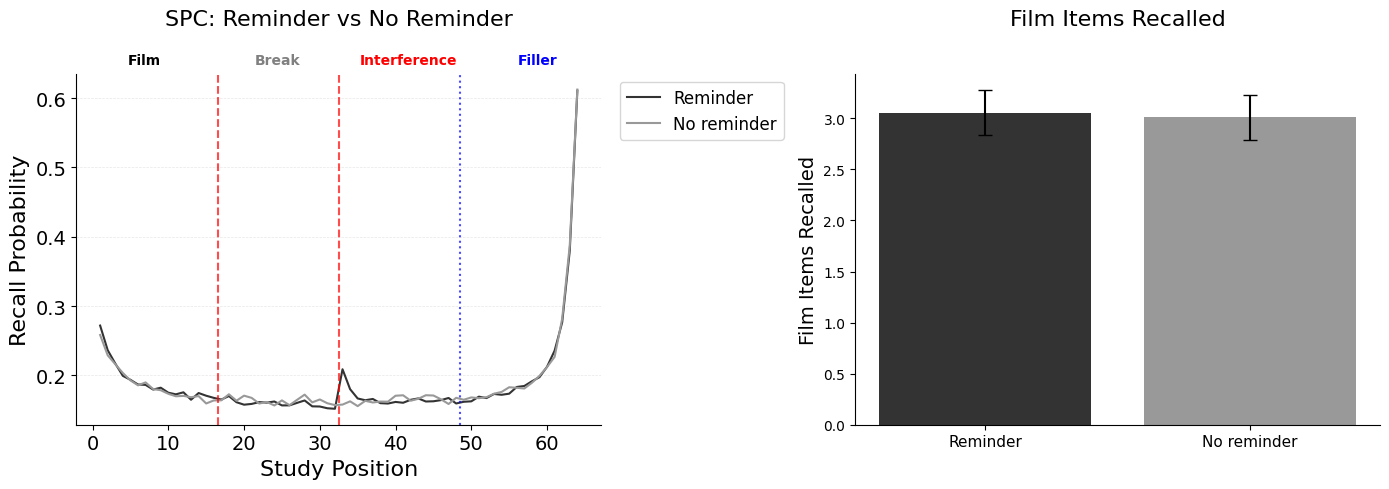

In [14]:
validation_spcs = [reminded_spc, no_reminder_spc]
validation_labels = ["Reminder", "No reminder"]
validation_colors = ["#333333", "#999999"]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_interference_spc(
    validation_spcs,
    validation_labels,
    N_FILM,
    n_break=N_BREAK_SHOWN,
    color_cycle=validation_colors,
    axis=axes[0],
)
add_filler_boundary(
    axes[0], N_FILM, N_INTERFERENCE, N_FILLER, STD_PRESENTED, n_break=N_BREAK_SHOWN
)
axes[0].set_title("SPC: Reminder vs No Reminder", fontsize=16, pad=35)

# Bar chart
conditions = validation_labels
bar_means = [reminded_stats[0], no_reminder_stats[0]]
bar_errs = [
    reminded_stats[0] - reminded_stats[1],
    no_reminder_stats[0] - no_reminder_stats[1],
]
x_pos = np.arange(len(conditions))
axes[1].bar(x_pos, bar_means, yerr=bar_errs, capsize=5, color=validation_colors)
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(conditions, fontsize=11)
axes[1].set_ylabel("Film Items Recalled", fontsize=14)
axes[1].set_title("Film Items Recalled", fontsize=16, pad=35)
for loc in ("top", "right"):
    axes[1].spines[loc].set_visible(False)

plt.tight_layout()
plt.show()

## Baseline SPC

With all calibration parameters set, this is the reference condition for subsequent simulations.
All 16 competitors are present with MCF scale = 1.0 — each interference item's MCF learning rate equals what it would receive as an ordinary study item at that position in the primacy gradient.
The default delay and reminder settings are applied.

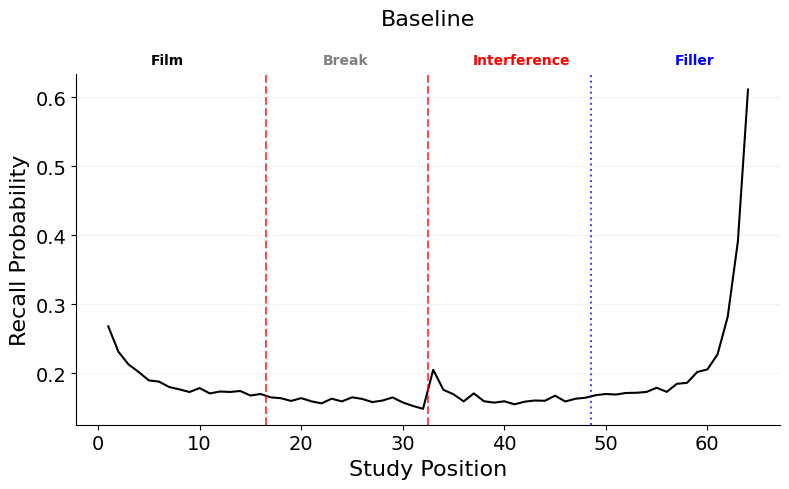

Film items recalled: 3.03 [2.81, 3.24]


In [15]:
rngs_2d, rng = sweep_rngs(rng, n_subjects, EXPERIMENT_COUNT)
baseline_recalls_3d = std_prep.batched(std_prep.models, rngs_2d, *std_prep.item_args)
baseline_recalls = baseline_recalls_3d.reshape(-1, baseline_recalls_3d.shape[-1])
baseline_recalls = standard_remap(baseline_recalls, paradigm)
baseline_spc = fixed_pres_spc(baseline_recalls, STD_PRESENTED)
baseline_stats = film_recalled_stats(baseline_recalls, paradigm, n_subjects)

fig, ax = plt.subplots(figsize=(8, 5))
plot_interference_spc(
    [baseline_spc], ["Baseline"], N_FILM, n_break=N_BREAK_SHOWN, color_cycle=["black"], axis=ax
)
add_filler_boundary(
    ax, N_FILM, N_INTERFERENCE, N_FILLER, STD_PRESENTED, n_break=N_BREAK_SHOWN
)
ax.set_title("Baseline", fontsize=16, pad=35)
ax.get_legend().remove()
fig.tight_layout()
plt.show()

mu, lo, hi = baseline_stats
print(f"Film items recalled: {mu:.2f} [{lo:.2f}, {hi:.2f}]")